# YARP Tutorial 2: Product Enumeration and The Reaction Class

## Section A: Product Enumeration

Here we will cover the two modes of enumeration: concerted and sequential.

We will also cover the post-enumeration filtering options:
- Lewis score
- Formal charge
- Strained rings

For this tutorial, we will be using the `enumerate_products()` function, which conveniently wraps all underlying enumeration codes.
This function returns a list of `yarpecule` objects generated by enumeration.

In [1]:
import yarp as yp
from yarp.reaction.generate_rxns import enumerate_products

```
def enumerate_products(r_yp, n_break, n_form, react=[], mode="concerted", l_cutoff=0.0, fc_cutoff=2.0, ring_filter=False):
    """
    r_yp : yarpecule object
        The reactant from which all products are enumerated

    n_break : int
        Number of bonds to break

    n_form : int
        Number of bonds to form

    react : set (default = None)
        When supplied this is used to restrict bond formations only to those atoms in this set.
        If supplied, then `react` must have a searchable list or set
        (i.e., the function uses an `in` call, so sets are better) per `yarpecule`.
        An empty list is interpreted as all atoms being available to react. 

    mode : string
        Toggle between the two available product enumeration modes:
        concerted (default) and sequential enumeration.

    l_cutoff : float (default = 0.0)
        Threshold used in sequential enumeration to discard unphysical Lewis structures
        with bond-electron matrix scores above this value.

    fc_cutoff : float (default = 2.0)
        Threshold used in sequential enumeration to discard unphysical Lewis structures
        with total formal charges at or above this value.

    ring_filter : bool (default = False)
        Filter out 3 and 4 member rings from enumerated products.
    """
```

### Concerted vs. Sequential Enumeration

Concerted enumeration
- Bonds are defined by bond order
- Bond breaking and forming happen in one-shot
- Bond formation is restricted to atoms involved in bond breakage
- More rigorous "reasonability" checks are baked into the product enumeration routine (i.e. no dangling bonds, no zwitterions)

Sequential enumeration
- Bonds are defined by connectivity
- Bond breaking and forming happen in two distinct steps
- Bond formation can occur between any atoms in the molecule/system
- Valence and pi bond electrons are allowed to move freely to fill in the final structure
- "Reasonability" checks are performed after product enumeration routine to **allow for more comprehensive enumeration**

In short, sequential *should* find all of the same structures as concerted enumeration, plus some additional structures - which may be unphysical!

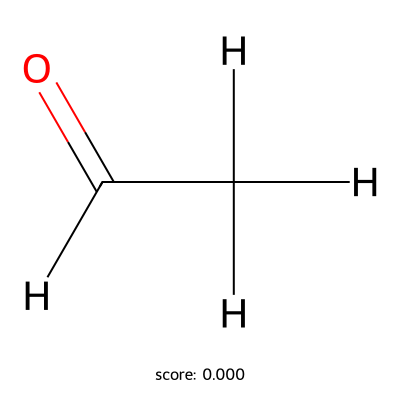

In [2]:
haa = yp.yarpecule('CC=O')
haa.draw_bmats(show_inline=True)

For concerted enumeration, only 3 possible structures can be formed (excluding the reforming of the original reactant via H exchange).

Notice also that the application of "reasonability filters" after enumeration does not eliminate any products.

  * Product enumeration with break 2, form 2 will be performed in concerted mode.
   + Enumerated 3 products
   + Applying Lewis score cutoff of 0.0
   + Applying formal charge cutoff of 2.0
   + Returning 3 products after filtering


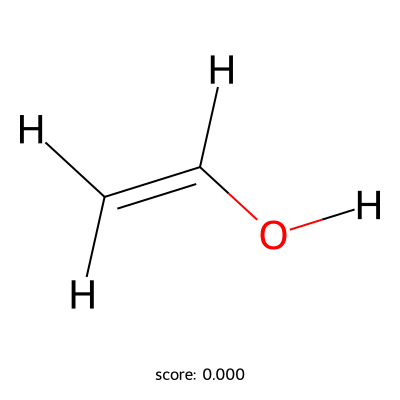

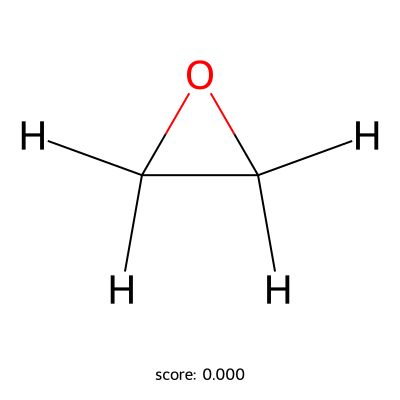

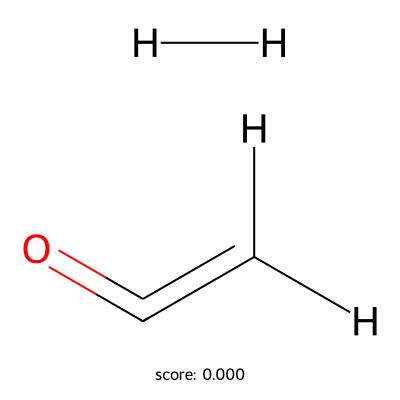

In [3]:
haa_conc_b2f2 = enumerate_products(haa, n_break=2, n_form=2, mode='concerted')
for _ in haa_conc_b2f2:
    _.draw_bmats(show_inline=True)

In sequential enumeration, the same b2f2 exploration of the same molecule results in 33 potential products!!

Most of these are "unreasonable", so when we apply our filters, we extract the same products found (more efficiently) by concerted enumeration.

  * Product enumeration with break 2, form 2 will be performed in sequential mode.
   + Breaking 2 bonds formed 6 intermediates
   + Forming 2 bonds formed 33 potential products
   + Applying Lewis score cutoff of 0.0
   + Applying formal charge cutoff of 2.0
   + Returning 3 products after filtering


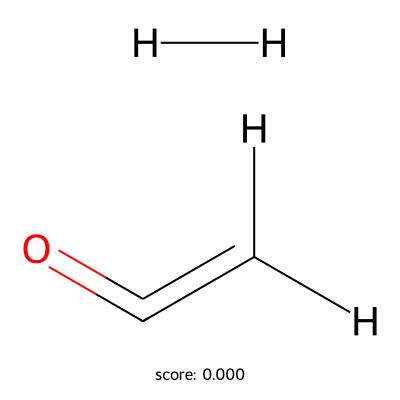

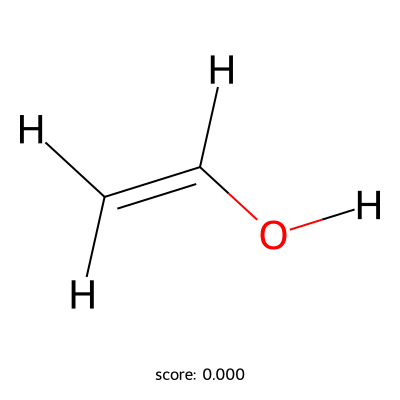

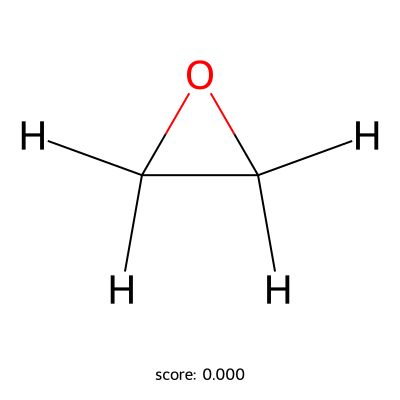

In [4]:
haa_seq_b2f2 = enumerate_products(haa, n_break=2, n_form=2, mode='sequential')
for _ in haa_seq_b2f2:
    _.draw_bmats(show_inline=True)

Why even bother with sequential enumeration then?
- It gives us more flexibility to discover certain chemistries than concerted enumeration
- For instance, it's the only option we have for generating radicals from closed-shell species.

Here is a break-2, form-1 enumeration, which will leave unpaired electrons in the final product.
- NOTE: We must change the default Lewis score cutoff, as unpaired electrons almost always result in a score > 0.0

  * Product enumeration with break 2, form 1 will be performed in sequential mode.
   + Breaking 2 bonds formed 6 intermediates
   + Forming 1 bonds formed 16 potential products
   + Applying Lewis score cutoff of 5.0
   + Applying formal charge cutoff of 2.0
   + Returning 3 products after filtering


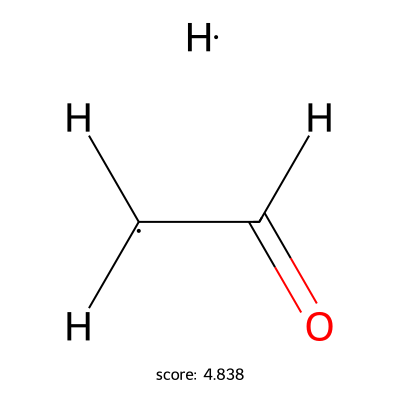

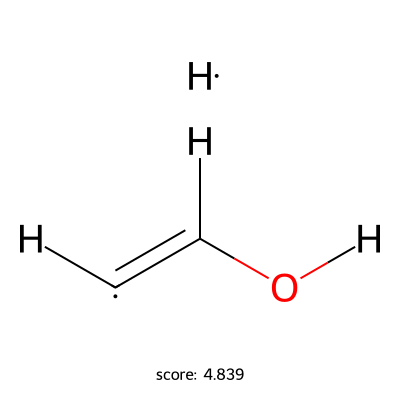

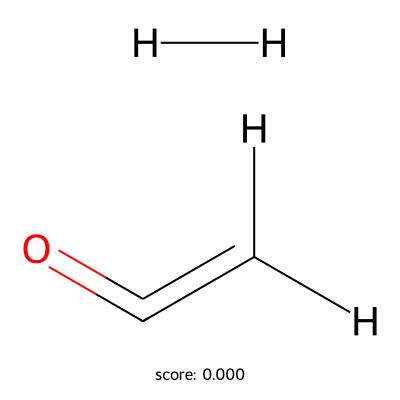

In [11]:
haa_seq_b2f1 = enumerate_products(haa, n_break=2, n_form=1, mode='sequential', l_cutoff=5.0)
for _ in haa_seq_b2f1:
    _.draw_bmats(show_inline=True)

Concerted enumeration is not able to form radical species

  * Product enumeration with break 2, form 1 will be performed in concerted mode.
   + Enumerated 3 products
   + Applying Lewis score cutoff of 5.0
   + Applying formal charge cutoff of 2.0
   + Returning 3 products after filtering


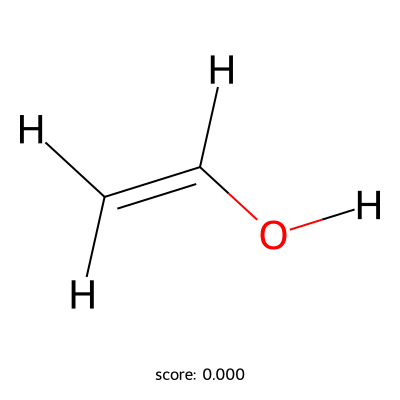

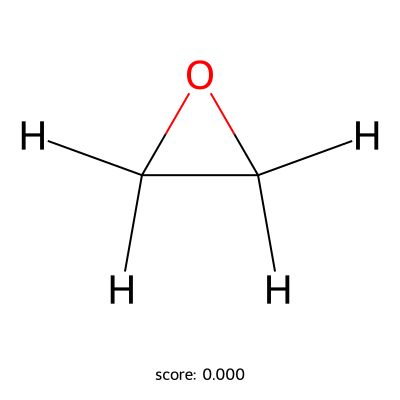

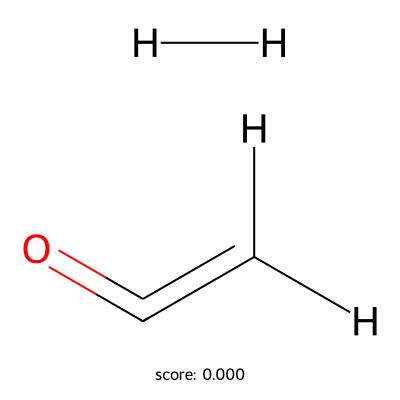

In [9]:
haa_conc_b2f1 = enumerate_products(haa, n_break=2, n_form=1, mode='concerted', l_cutoff=5.0)
for _ in haa_conc_b2f1:
    _.draw_bmats(show_inline=True)

### How many bonds to break?

Most closed-shell organic chemistry can be explored using a series of concerted break-2, form-2 (b2f2) enumeration rounds.

For some cases, such as the famous Diels-Alder reaction, a concerted break-3, form-3 (b3f3) reaction is the preferred mechanism.

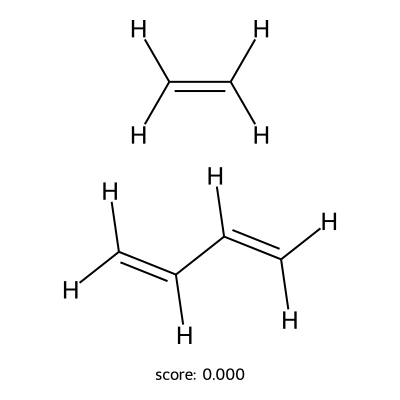

In [12]:
dar = yp.yarpecule('C=CC=C.C=C')
dar.draw_bmats(show_inline=True)

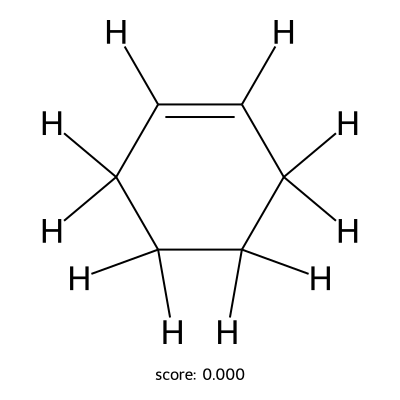

In [15]:
dap = yp.yarpecule('C1C=CCCC1')
dap.draw_bmats(show_inline=True)

In [18]:
dar_conc_b2f2 = enumerate_products(dar, n_break=2, n_form=2, mode='concerted')

dar_conc_b2f2_set = set()
for _ in dar_conc_b2f2:
    dar_conc_b2f2_set.add(_.hash)

print(f"DA product present? {dap.hash in dar_conc_b2f2_set}")

  * Product enumeration with break 2, form 2 will be performed in concerted mode.
   + Enumerated 17 products
   + Applying Lewis score cutoff of 0.0
   + Applying formal charge cutoff of 2.0
   + Returning 16 products after filtering
DA product present? False


In [19]:
dar_conc_b3f3 = enumerate_products(dar, n_break=3, n_form=3, mode='concerted')

dar_conc_b3f3_set = set()
for _ in dar_conc_b3f3:
    dar_conc_b3f3_set.add(_.hash)

print(f"DA product present? {dap.hash in dar_conc_b3f3_set}")

  * Product enumeration with break 3, form 3 will be performed in concerted mode.
   + Enumerated 49 products
   + Applying Lewis score cutoff of 0.0
   + Applying formal charge cutoff of 2.0
   + Returning 47 products after filtering
DA product present? True


As you can see, b3f3 is much more expensive than b2f2.

However, if you need to do b3f3, you can have confidence that you will discover all of the "lower order" b2f2 products in addition to b3f3!

In [23]:
overlap = dar_conc_b2f2_set & dar_conc_b3f3_set

print(f"b3f3 found {len(overlap)} out of {len(dar_conc_b2f2_set)} b2f2 products!")

b3f3 found 16 out of 16 b2f2 products!


Fun fact: With how sequential enumeration defines bonds, the Diels-Alder reaction is a break-0, form-2 reaction!

I couldn't get it to work with actually specifying break-0 (add that to the unit testing to-do list), but a break-1, form-2 returns the desired product

In [22]:
dar_seq_b0f2 = enumerate_products(dar, n_break=1, n_form=2, mode='sequential')

dar_seq_b1f2_set = set()
for _ in dar_seq_b0f2:
    dar_seq_b1f2_set.add(_.hash)

print(f"DA product present? {dap.hash in dar_seq_b1f2_set}")

  * Product enumeration with break 1, form 2 will be performed in sequential mode.
   + Breaking 1 bonds formed 4 intermediates
   + Forming 2 bonds formed 229 potential products
   + Applying Lewis score cutoff of 0.0
   + Applying formal charge cutoff of 2.0
   + Returning 41 products after filtering
DA product present? True


### Enumerating from resonance structures

The presence of resonance structures **AND** valence electrons results in a dramatic cost explosion for sequential enumeration!

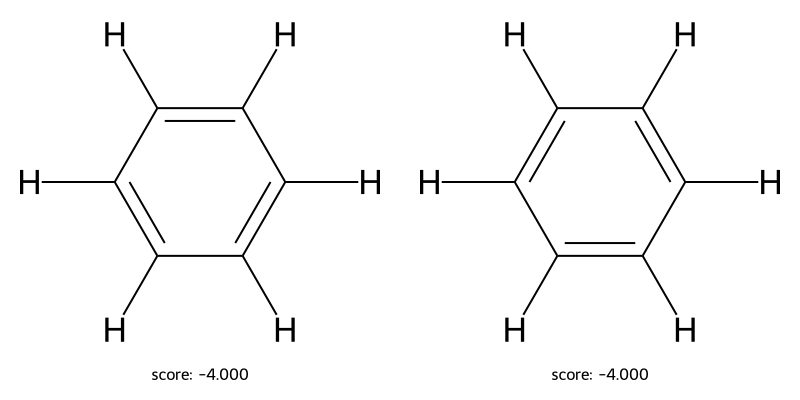

In [32]:
benz_smi = "c1ccccc1"
benz_mol = yp.yarpecule(benz_smi)
benz_mol.draw_bmats(show_inline=True)

In [33]:
benz_seq_b2f2 = enumerate_products(benz_mol, n_break=2, n_form=2, mode='sequential')

  * Product enumeration with break 2, form 2 will be performed in sequential mode.
   + Breaking 2 bonds formed 16 intermediates
   + Forming 2 bonds formed 722 potential products
   + Applying Lewis score cutoff of 0.0
   + Applying formal charge cutoff of 2.0
   + Returning 80 products after filtering


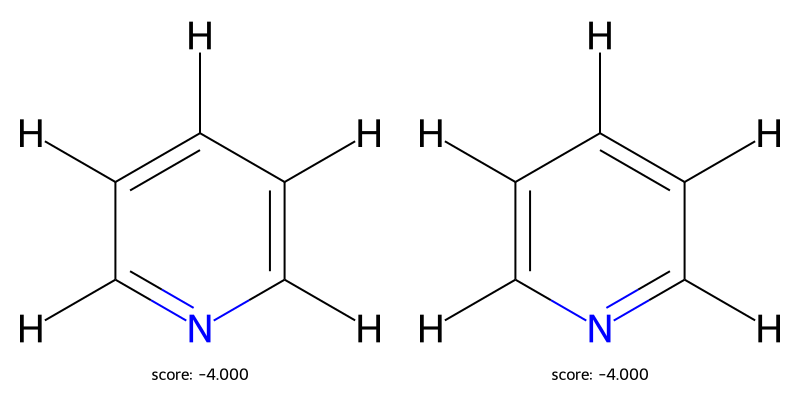

In [24]:
nbenz_smi = "n1ccccc1"
nbenz_mol = yp.yarpecule(nbenz_smi)
nbenz_mol.draw_bmats(show_inline=True)

In [26]:
nbenz_seq_b2f2 = enumerate_products(nbenz_mol, n_break=2, n_form=2, mode='sequential')

  * Product enumeration with break 2, form 2 will be performed in sequential mode.
   + Breaking 2 bonds formed 36 intermediates
   + Forming 2 bonds formed 3814 potential products
   + Applying Lewis score cutoff of 0.0
   + Applying formal charge cutoff of 2.0
   + Returning 241 products after filtering


Bimolecular enumeration adds an additional cost!

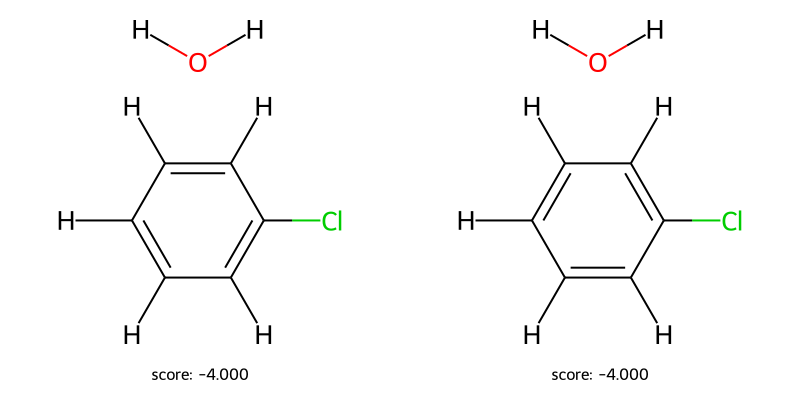

In [27]:
snar_r = yp.yarpecule('c1ccccc1Cl.O')
snar_r.draw_bmats(show_inline=True)

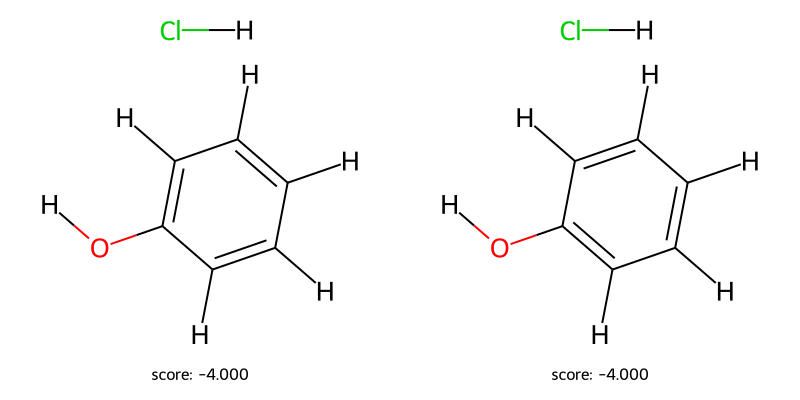

In [28]:
snar_p = yp.yarpecule('c1ccccc1O.Cl')
snar_p.draw_bmats(show_inline=True)

This is pretty much why we have re-implemented concerted enumeration in YARP-again.... it's SO much faster!

In [30]:
snar_conc_b2f2 = enumerate_products(snar_r, n_break=2, n_form=2, mode='concerted')

snar_conc_b2f2_set = set()
for _ in snar_conc_b2f2:
    snar_conc_b2f2_set.add(_.hash)

print(f"Product found? {snar_p.hash in snar_conc_b2f2_set}")

  * Product enumeration with break 2, form 2 will be performed in concerted mode.
   + Enumerated 13 products
   + Applying Lewis score cutoff of 0.0
   + Applying formal charge cutoff of 2.0
   + Returning 5 products after filtering
Product found? True


I ran out of patience here, feel free to wait for 1-2 hours for this to finish on your own time!

In [34]:
snar_seq_b2f2 = enumerate_products(snar_r, n_break=2, n_form=2, mode='sequential')

snar_seq_b2f2_set = set()
for _ in snar_seq_b2f2:
    snar_seq_b2f2_set.add(_.hash)

print(f"Product found? {snar_p.hash in snar_seq_b2f2_set}")

  * Product enumeration with break 2, form 2 will be performed in sequential mode.
   + Breaking 2 bonds formed 61 intermediates


## Section B: Reaction Object Class

Ok, so you have your enumerated products, but now what do you do with them?

YARP-again stores pairs of reactant-product yarpecules inside of reaction class objects! Let's look at the structure of a reaction class.

In [36]:
from yarp.reaction.reaction import reaction

The reaction class is initialized with several placeholders for downstream applications (i.e. reaction characterization)

```
class reaction:
    """
    Base class for describing a reaction in YARP

    Parameters:
    -----------
    reactant : yarpecule
        Molecular graph of all species involved in the reactant-side state of the reaction

    product : yarpecule
        Molecular graph of all species involved in the product-side state of the reaction


    Attributes:
    -----------

    reactant : state object
        The reactant-side state of the reaction.
        Contains both molecular graph and conformer information.

    product : state object
        The product-side state of the reaction.
        Contains both molecular graph and conformer information.

    ts : dict
        Transition state geometry of the reaction.
        Key corresponds to level of theory, while the value should hold
        the actual 3D conformer geometry found at said level of theory.

    barrier : dict
        Energy of activation barrier (dG) of the reaction R --> P.
        Key corresponds to level of theory. dG values should be stored
        in units of kcal/mol.

    reverse_barrier : dict
        Energy of activation barrier (dG) of the reaction P --> R.
        Key corresponds to level of theory. dG values should be stored
        in units of kcal/mol.

    heat_of_reaction : dict
        Heat of reaction (dH) of the reaction R --> P.
        Key corresponds to level of theory. dH values should be stored
        in units of kcal/mol.

    max_flux : float
        Maximum reaction flux (units?) of the reaction R --> P.
        Initialized to zero, and intended as a placeholder to be updated
        by microkinetics run on a reaction network.

    id : str
        Name of reaction used to generate folders/files related to the reaction.
        This is NOT unique, but gives a reasonably human-readable label.

    hash : float
        Unique identifier for a reaction object.

    """
```

In [38]:
# Minimal functionality example from yarp/reactions/generate_reaction.py --> generate_rxns()

reactant = yp.yarpecule('CC=O')
products = enumerate_products(reactant, n_break=2, n_form=2)

output = dict()
for i, prod in enumerate(products):
    # Do a quick optimization to make product geometries reflect new bonding (needs debugging!)
    # prod = quick_geom_opt(prod, inp.quick_opt_lot)

    # Generate a reaction object from reactant/product pairs
    rxn = reaction(reactant, prod)

    # Add reaction to dictionary paired with its ID
    output[rxn.hash] = rxn

print(f"We now have {len(output)} reactions!")

  * Product enumeration with break 2, form 2 will be performed in concerted mode.
   + Enumerated 3 products
   + Applying Lewis score cutoff of 0.0
   + Applying formal charge cutoff of 2.0
   + Returning 3 products after filtering
We now have 3 reactions!


[10:54:05] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[10:54:05] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[10:54:05] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[10:54:05] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[10:54:05] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[10:54:05] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[10:54:05] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[10:54:05] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[10:54:05] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol

The reactant and product yarpecules now live in `state` objects, which store some helpful additional information

In [40]:
for rxn in output.values():
    print(rxn.id)
    print(f" - Product state: {rxn.product.canon_smi}")
    for mol in rxn.product.species:
        print(f"  + Species: {mol.canon_smi}")

IKHGUXGNUITLKF_to_IMROMDMJAWUWLK
 - Product state: C=CO
  + Species: C=CO
IKHGUXGNUITLKF_to_IAYPIBMASNFSPL
 - Product state: C1CO1
  + Species: C1CO1
IKHGUXGNUITLKF_to_CCGKOQOJPYTBIH-UFHFLCQGNIYNRP
 - Product state: C=C=O.[H][H]
  + Species: C=C=O
  + Species: [H][H]
